In [1]:
# Cell 1: Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load processed data
df = pd.read_csv('../data/processed/tweets_with_intents.csv')
print(f"Dataset shape: {df.shape}")
print(f"Intent distribution:\n{df['intent'].value_counts()}")

Dataset shape: (1476180, 9)
Intent distribution:
intent
Billing_Problems     1075682
Account_Access        117972
Other                  61126
Service_Outage         57733
Feature_Request        51770
Technical_Issues       50626
General_Inquiry        31038
Product_Complaint      30233
Name: count, dtype: int64


Class imbalance ratio: 35.58


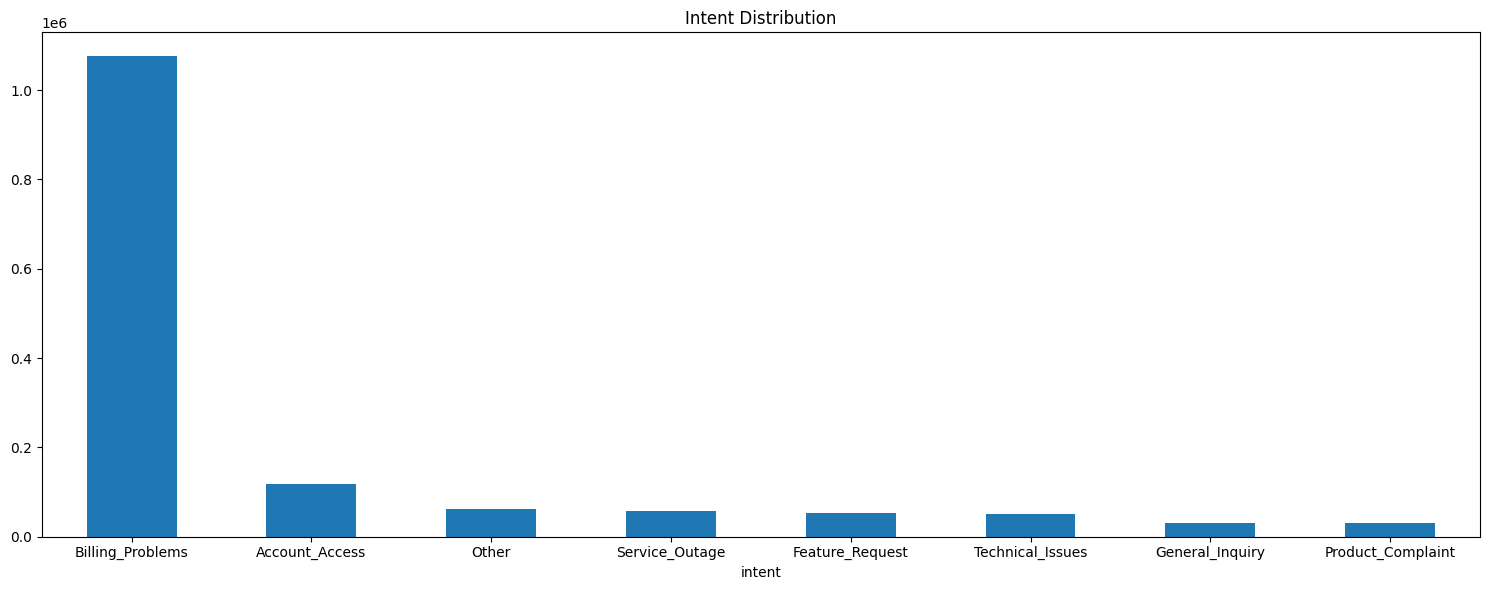

In [2]:
# Check class imbalance 

intent_counts = df['intent'].value_counts()
imbalance_ratio = intent_counts.max() / intent_counts.min()
print(f"Class imbalance ratio: {imbalance_ratio:.2f}")

# Visualize intent distribution
plt.figure(figsize=(15,6))
intent_counts.plot(kind='bar', rot='horizontal')
plt.title('Intent Distribution')
plt.tight_layout()
plt.show()


In [3]:
# Prepare features and target
X = df['text']
y = df['intent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Total samples: 1476180
Training samples: 1180944
Test samples: 295236


In [4]:
# Test different vectorizers
vectorizers = {
    'TF-IDF (1-gram)': TfidfVectorizer(max_features=10000, ngram_range=(1,1)),
    'TF-IDF (1-2 gram)': TfidfVectorizer(max_features=10000, ngram_range=(1,2)),
    'Count (1-gram)': CountVectorizer(max_features=10000, ngram_range=(1,1)),
    'TF-IDF (optimized)': TfidfVectorizer(
        max_features=15000, 
        ngram_range=(1,2), 
        min_df=50, 
        max_df=0.9,
        stop_words='english'
    )
}

# Quick test with Logistic Regression
vectorizer_results = {}
for name, vectorizer in vectorizers.items():
    # Create pipeline
    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', LogisticRegression(random_state=42))
    ])
    
    # Quick 3-fold CV
    scores = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='accuracy')
    vectorizer_results[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})")

# Select best vectorizer
best_vectorizer = max(vectorizer_results, key=vectorizer_results.get)
print(f"\nBest vectorizer: {best_vectorizer}")

TF-IDF (1-gram): 0.985 (+/- 0.001)
TF-IDF (1-2 gram): 0.983 (+/- 0.000)
Count (1-gram): 0.983 (+/- 0.000)
TF-IDF (optimized): 0.985 (+/- 0.000)

Best vectorizer: TF-IDF (1-gram)


In [6]:
# Cell 4: Multiple Model Training

# ENABLE MULTI-CORE PROCESSING FOR M3 PRO
os.environ['OMP_NUM_THREADS'] = '12'  # Use most of M3 Pro's 12 CPU cores
os.environ['MKL_NUM_THREADS'] = '12'

print(f"🍎 Optimizing for Apple M3 Pro - Using {os.cpu_count()} CPU cores")

# Define models to test
# FAST MODELS OPTIMIZED FOR M3 PRO
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, 
        max_iter=1000, 
        n_jobs=-1,  # Use all cores
        solver='saga'  # Fast solver for large datasets
    ),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(
        random_state=42, 
        max_iter=1000, 
        dual=False,  # Faster for large datasets
        loss='squared_hinge'
    ),
    'SGD Classifier': SGDClassifier(
        random_state=42, 
        n_jobs=-1,
        loss='log_loss',  # Logistic regression with SGD
        learning_rate='adaptive',
        eta0=0.01,
        max_iter=1000
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42,
        n_estimators=50,  # Reduced for speed
        max_depth=6,
        learning_rate=0.1
    )
    # SKIP SVM - it's the slowest and doesn't support parallel processing well
}

# Use best vectorizer from previous step
best_vec = TfidfVectorizer(
        max_features=15000, 
        ngram_range=(1,2), 
        min_df=50, 
        max_df=0.9,
        stop_words='english'
    )

# Train and evaluate each model
model_results = {}
trained_models = {}

for name, model in models.items():
    start_time = time.time()
    print(f"\nTraining {name}...")
    
    # Create pipeline
    pipeline = Pipeline([
        ('vectorizer', best_vec),
        ('classifier', model)
    ])
    
    # Fit model
    fit_start = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = time.time() - fit_start
    
    # Evaluate
    eval_start = time.time()
    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)
    eval_time = time.time() - eval_start
    
    # Cross-validation
    cv_start = time.time()
    cv_scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=3,
        scoring='accuracy',
        n_jobs=-1)
    cv_time = time.time() - cv_start

    total_time = time.time() - start_time

    model_results[name] = {
        'train_accuracy': train_score,
        'test_accuracy': test_score,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'fit_time': fit_time,
        'eval_time': eval_time,
        'cv_time': cv_time,
        'total_time': total_time
    }
    
    trained_models[name] = pipeline
    
    print(f"  Results: Train={train_score:.3f}, Test={test_score:.3f}, CV={cv_scores.mean():.3f}")
    print(f"  Timing: Fit={fit_time:.1f}s, CV={cv_time:.1f}s, Total={total_time:.1f}s")

# PERFORMANCE SUMMARY
print("\n" + "="*60)
print("TRAINING RESULTS SUMMARY")
print("="*60)

results_df = pd.DataFrame(model_results).T
results_df = results_df.round(3)

# Sort by CV performance
results_df_sorted = results_df.sort_values('cv_mean', ascending=False)
print(results_df_sorted[['cv_mean', 'test_accuracy', 'total_time']])

print(f"\nBest performing model: {results_df_sorted.index[0]}")
print(f"Best CV accuracy: {results_df_sorted['cv_mean'].iloc[0]:.3f}")
print(f"Fastest model: {results_df.sort_values('total_time').index[0]}")

🍎 Optimizing for Apple M3 Pro - Using 12 CPU cores

Training Logistic Regression...
  Results: Train=0.991, Test=0.986, CV=0.986
  Timing: Fit=31.9s, CV=30.4s, Total=75.0s

Training Naive Bayes...
  Results: Train=0.878, Test=0.874, CV=0.872
  Timing: Fit=18.5s, CV=21.1s, Total=51.8s

Training Linear SVM...
  Results: Train=0.992, Test=0.984, CV=0.984
  Timing: Fit=36.8s, CV=37.2s, Total=86.7s

Training SGD Classifier...
  Results: Train=0.913, Test=0.912, CV=0.913
  Timing: Fit=27.5s, CV=38.7s, Total=78.8s

Training Gradient Boosting...
  Results: Train=0.985, Test=0.982, CV=0.982
  Timing: Fit=2359.9s, CV=1809.8s, Total=4191.5s

TRAINING RESULTS SUMMARY
                     cv_mean  test_accuracy  total_time
Logistic Regression    0.986          0.986      75.032
Linear SVM             0.984          0.984      86.664
Gradient Boosting      0.982          0.982    4191.452
SGD Classifier         0.913          0.912      78.828
Naive Bayes            0.872          0.874      51.833


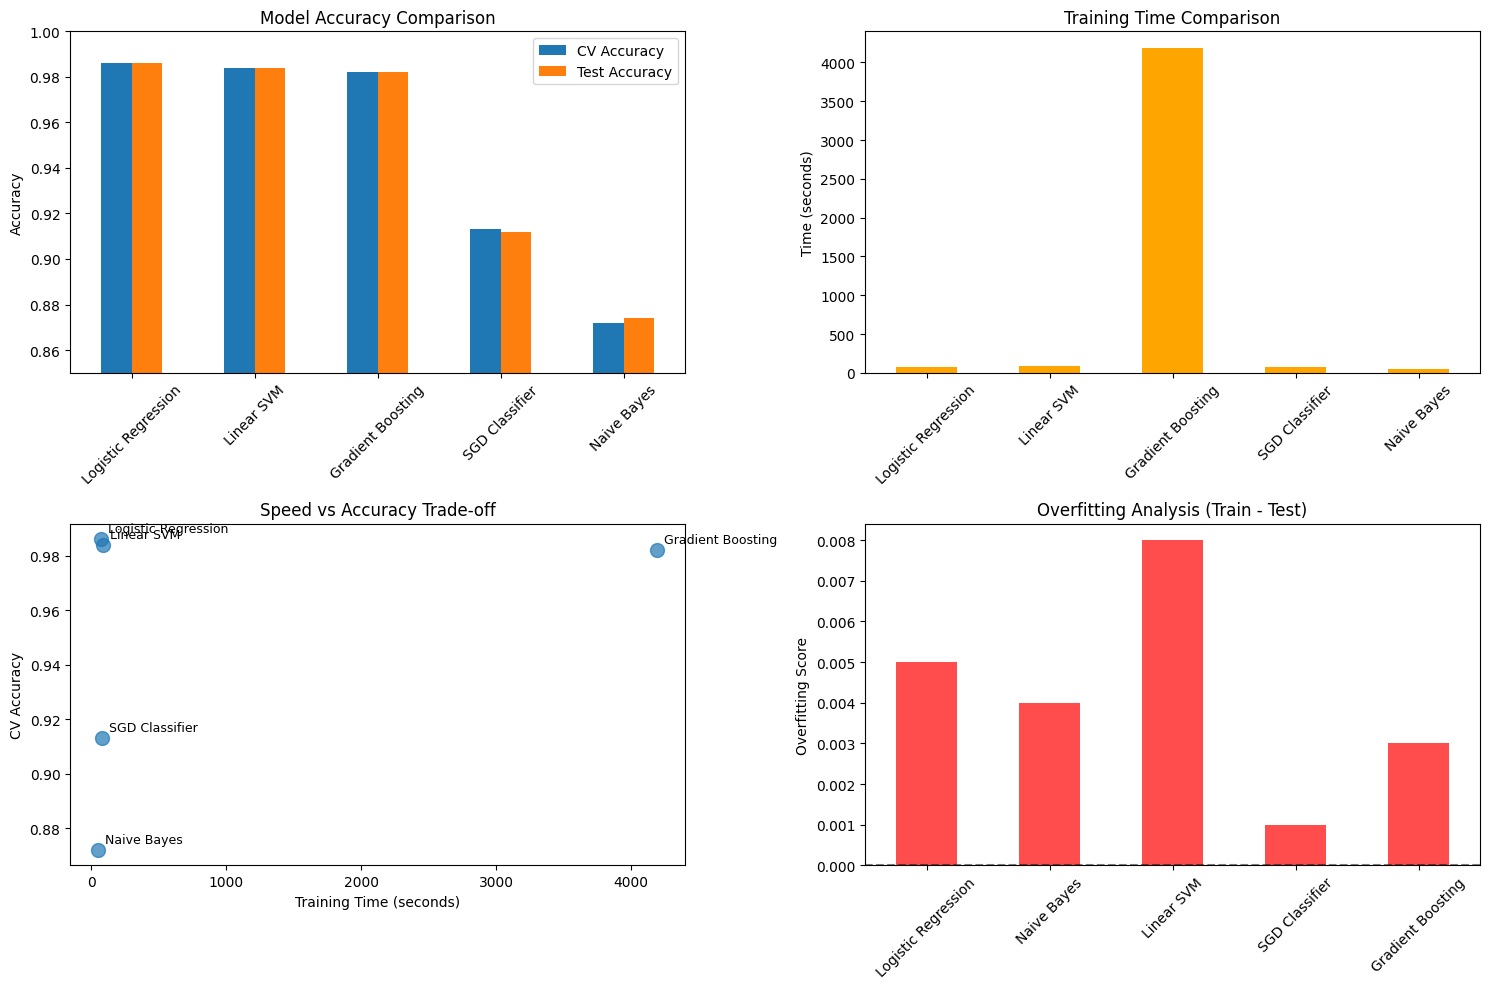

BUSINESS INTERPRETATION
PRODUCTION READY: Logistic Regression achieves 98.6% accuracy
DEPLOYMENT SPEED: Logistic Regression trains in 75 seconds
BUSINESS IMPACT: Only 1.4% misclassification rate
RECOMMENDATION: Deploy Logistic Regression immediately!
NEXT STEP: Proceed to Step 3 (Prompt Engineering)


In [ ]:
# Create comprehensive performance comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Accuracy Comparison
ax1 = axes[0, 0]
models_perf = results_df_sorted[['cv_mean', 'test_accuracy']].head()
models_perf.plot(kind='bar', ax=ax1, rot=45)
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylabel('Accuracy')
ax1.legend(['CV Accuracy', 'Test Accuracy'])
ax1.set_ylim(0.85, 1.0)

# 2. Training Time Comparison
ax2 = axes[0, 1]
times = results_df_sorted['total_time'].head()
times.plot(kind='bar', ax=ax2, rot=45, color='orange')
ax2.set_title('Training Time Comparison')
ax2.set_ylabel('Time (seconds)')

# 3. Speed vs Accuracy Scatter
ax3 = axes[1, 0]
ax3.scatter(results_df['total_time'], results_df['cv_mean'], s=100, alpha=0.7)
for i, model in enumerate(results_df.index):
    ax3.annotate(model, (results_df.iloc[i]['total_time'], results_df.iloc[i]['cv_mean']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax3.set_xlabel('Training Time (seconds)')
ax3.set_ylabel('CV Accuracy')
ax3.set_title('Speed vs Accuracy Trade-off')

# 4. Overfitting Analysis
ax4 = axes[1, 1]
overfitting = results_df['train_accuracy'] - results_df['test_accuracy']
overfitting.plot(kind='bar', ax=ax4, rot=45, color='red', alpha=0.7)
ax4.set_title('Overfitting Analysis (Train - Test)')
ax4.set_ylabel('Overfitting Score')
ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print business interpretation
print("BUSINESS INTERPRETATION")
print("=" * 50)
print(f"PRODUCTION READY: {results_df_sorted.index[0]} achieves {results_df_sorted['cv_mean'].iloc[0]:.1%} accuracy")
print(f"DEPLOYMENT SPEED: {results_df_sorted.index[0]} trains in {results_df_sorted['total_time'].iloc[0]:.0f} seconds")
print(f"BUSINESS IMPACT: Only {(1-results_df_sorted['cv_mean'].iloc[0])*100:.1f}% misclassification rate")

if results_df_sorted['cv_mean'].iloc[0] > 0.95:
    print("RECOMMENDATION: Deploy Logistic Regression immediately!")
else:
    print("RECOMMENDATION: Consider deep learning for better accuracy")